# Customer Segmentation & Lifetime Value Analysis
### Olist Brazilian E-Commerce | RFM + K-Means + Probabilistic CLV

---

**The question:** Where should a growing e-commerce company spend its retention budget?

**The dataset:** 99K customers, 96K delivered orders, $15.4M in revenue across 2 years (2016–2018).

**The approach:**
1. **RFM scoring** — segment customers by Recency, Frequency, and Monetary value
2. **K-Means clustering** — validate that the segments are real, not arbitrary
3. **BG/NBD + Gamma-Gamma CLV** — forecast each segment's forward 12-month value

**Author:** Sivakumar Reddy Yenna

In [2]:
# =====================================================================
# Imports & Database Connection
# =====================================================================
# Credentials are loaded from a .env file at the project root.
# .env is excluded from Git (see .gitignore) to keep secrets out of
# the repo. To reproduce this notebook, create a .env file with:
#   DB_USER=postgres
#   DB_PASSWORD=your_password_here
#   DB_HOST=localhost
#   DB_PORT=5432
#   DB_NAME=olist
# =====================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from datetime import datetime
from urllib.parse import quote_plus
from dotenv import load_dotenv

# Visual settings
plt.style.use('default')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Load environment variables from .env (one level up from notebooks/)
load_dotenv(dotenv_path='../.env')

# Read database credentials from environment
DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = os.getenv('DB_PORT')
DB_NAME     = os.getenv('DB_NAME')

# Validate that all required variables loaded successfully
required_vars = {'DB_USER': DB_USER, 'DB_PASSWORD': DB_PASSWORD,
                 'DB_HOST': DB_HOST, 'DB_PORT': DB_PORT, 'DB_NAME': DB_NAME}
missing = [k for k, v in required_vars.items() if not v]
if missing:
    raise ValueError(
        f"Missing environment variables: {missing}. "
        f"Make sure a .env file exists at the project root."
    )

# Build connection string — quote_plus URL-encodes special characters
# in the password (e.g., '@' which would otherwise break the URL parsing)
engine = create_engine(
    f'postgresql+psycopg2://'
    f'{DB_USER}:{quote_plus(DB_PASSWORD)}'
    f'@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print("Imports loaded ✓")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")
print(f"Database:       {DB_NAME} @ {DB_HOST}:{DB_PORT}")
print(f"User:           {DB_USER}")
print(f"Password:       {'*' * len(DB_PASSWORD)}  (masked, loaded from .env)")

Imports loaded ✓
Pandas version: 3.0.3
NumPy version:  2.4.6
Database:       olist @ localhost:5432
User:           postgres
Password:       **************  (masked, loaded from .env)


In [3]:
# =====================================================================
# Test database connection
# =====================================================================

# Run a simple query to confirm we can talk to the database
test_query = "SELECT COUNT(*) AS total_rows FROM customer_transactions;"
test_result = pd.read_sql(test_query, engine)

print("Database connection successful ✓")
print(test_result)

Database connection successful ✓
   total_rows
0       96469


In [4]:
# =====================================================================
# Load customer_transactions view into a pandas DataFrame
# =====================================================================

query = """
SELECT
    customer_unique_id,
    order_id,
    order_purchase_timestamp,
    order_delivered_customer_date,
    payment_value,
    num_items,
    customer_state,
    customer_city
FROM customer_transactions;
"""

# Pull all 96,469 transactions into a DataFrame
df = pd.read_sql(query, engine, parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date'])

print(f"Rows loaded: {len(df):,}")
print(f"Unique customers: {df['customer_unique_id'].nunique():,}")
print(f"Columns: {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Rows loaded: 96,469
Unique customers: 93,349
Columns: ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'payment_value', 'num_items', 'customer_state', 'customer_city']
Memory usage: 28.0 MB


In [5]:
# =====================================================================
# Eyeball the data
# =====================================================================

# Look at the first 5 rows
print("--- First 5 rows ---")
display(df.head())

# Summary statistics on numeric columns
print("\n--- Numeric summary ---")
display(df.describe())

# Data types — confirm timestamps parsed correctly
print("\n--- Data types ---")
print(df.dtypes)

--- First 5 rows ---


,customer_unique_id,order_id,order_purchase_timestamp,order_delivered_customer_date,payment_value,num_items,customer_state,customer_city
0,eb28e67c4c0b83846050ddfb8a35d051,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-12 16:04:24,259.83,1,SP,santa fe do sul
1,3818d81c6709e39d06b2738a8d3a2474,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-22 13:19:16,216.87,1,MG,para de minas
2,107e6259485efac66428a56f10801f4f,00061f2a7bc09da83e415a52dc8a4af1,2018-03-24 22:16:10,2018-03-29 00:04:19,68.87,1,SP,piracicaba
3,3fb97204945ca0c01bcf3eee6031c5f1,00063b381e2406b52ad429470734ebd5,2018-07-27 17:21:27,2018-08-07 13:56:52,57.98,1,SP,monte alto
4,7ed0ea20347f67fe61d1c99fdf8556ae,0006ec9db01a64e59a68b2c340bf65a7,2018-07-24 17:04:17,2018-07-31 01:04:15,97.32,1,RJ,rio de janeiro



--- Numeric summary ---


,order_purchase_timestamp,order_delivered_customer_date,payment_value,num_items
count,96469,96469,"96,469.00","96,469.00"
mean,2018-01-01 23:24:47.665975,2018-01-14 12:47:59.778654,159.86,1.14
min,2016-10-03 09:44:50,2016-10-11 13:46:32,9.59,1.00
25%,2017-09-14 08:57:12,2017-09-25 22:18:08,61.88,1.00
50%,2018-01-20 19:37:42,2018-02-02 19:36:08,105.28,1.00
75%,2018-05-05 18:30:17,2018-05-15 22:56:45,176.33,1.00
max,2018-08-29 15:00:37,2018-10-17 13:22:46,"13,664.08",21.00
std,NaN,NaN,218.82,0.54



--- Data types ---
customer_unique_id                          str
order_id                                    str
order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
payment_value                           float64
num_items                                 int64
customer_state                              str
customer_city                               str
dtype: object


In [6]:
# =====================================================================
# Set snapshot date for Recency calculation
# =====================================================================

# Latest order in the data + 1 day = snapshot date
SNAPSHOT_DATE = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(f"Latest purchase in data: {df['order_purchase_timestamp'].max()}")
print(f"Snapshot date for Recency: {SNAPSHOT_DATE}")
print(f"Analysis window: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")

Latest purchase in data: 2018-08-29 15:00:37
Snapshot date for Recency: 2018-08-30 15:00:37
Analysis window: 2016-10-03 → 2018-08-29


In [7]:
# =====================================================================
# Compute RFM values per customer
# =====================================================================

rfm = df.groupby('customer_unique_id').agg(
    last_purchase=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

# Recency = days since last purchase (relative to snapshot)
rfm['recency'] = (SNAPSHOT_DATE - rfm['last_purchase']).dt.days

# Drop the helper column — we only need recency in days
rfm = rfm.drop(columns=['last_purchase'])

# Reorder columns for readability
rfm = rfm[['customer_unique_id', 'recency', 'frequency', 'monetary']]

print(f"RFM table shape: {rfm.shape}")
print(f"\n--- First 5 customers ---")
display(rfm.head())

print(f"\n--- RFM summary ---")
display(rfm.describe())

RFM table shape: (93349, 4)

--- First 5 customers ---


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89



--- RFM summary ---


,recency,frequency,monetary
count,"93,349.00","93,349.00","93,349.00"
mean,237.94,1.03,165.20
std,152.58,0.21,226.32
min,1.00,1.00,9.59
25%,114.00,1.00,63.05
50%,219.00,1.00,107.78
75%,346.00,1.00,182.55
max,695.00,15.00,"13,664.08"


In [8]:
# =====================================================================
# Quintile-based RFM scoring
# =====================================================================

# RECENCY scoring (lower recency = better, so we reverse: most recent = 5)
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# MONETARY scoring (higher monetary = better)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# FREQUENCY scoring (custom because 96.88% have F=1)
# Anyone with F=1 gets a baseline score, anyone with F>=2 gets a higher score
def score_frequency(f):
    if f == 1:
        return 1
    elif f == 2:
        return 3
    elif f == 3:
        return 4
    else:  # f >= 4
        return 5

rfm['F_score'] = rfm['frequency'].apply(score_frequency).astype(int)

# Combined RFM_score as a string (for segment labeling later)
rfm['RFM_score'] = (
    rfm['R_score'].astype(str)
    + rfm['F_score'].astype(str)
    + rfm['M_score'].astype(str)
)

print("--- First 10 customers with scores ---")
display(rfm.head(10))

print("\n--- Distribution of R scores ---")
print(rfm['R_score'].value_counts().sort_index())

print("\n--- Distribution of F scores ---")
print(rfm['F_score'].value_counts().sort_index())

print("\n--- Distribution of M scores ---")
print(rfm['M_score'].value_counts().sort_index())

--- First 10 customers with scores ---


,customer_unique_id,recency,frequency,monetary,R_score,M_score,F_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,4,1,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,2,1,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,4,1,214
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4,4,1,414
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4,1,1,411
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,3,5,1,315
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,4,1,114
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,4,3,1,413



--- Distribution of R scores ---
R_score
1    18637
2    18576
3    18709
4    18705
5    18722
Name: count, dtype: int64

--- Distribution of F scores ---
F_score
1    90548
3     2573
4      181
5       47
Name: count, dtype: int64

--- Distribution of M scores ---
M_score
1    18672
2    18683
3    18657
4    18670
5    18667
Name: count, dtype: int64


In [9]:
# =====================================================================
# Assign customers to named segments
# =====================================================================

def assign_segment(row):
    R, F, M = row['R_score'], row['F_score'], row['M_score']

    # Champions: top customers across all dimensions
    if R >= 4 and F >= 4 and M >= 4:
        return 'Champions'

    # Loyal Customers: buy frequently, decent spend, may not be most recent
    elif F >= 4 and M >= 3:
        return 'Loyal Customers'

    # Potential Loyalists: recent + good spend, but only F=1 (could become loyal)
    elif R >= 4 and M >= 4:
        return 'Potential Loyalists'

    # New Customers: very recent (R=5), low frequency/spend
    elif R == 5:
        return 'New Customers'

    # At Risk: used to spend a lot, but haven't been around recently
    elif R <= 2 and M >= 4:
        return 'At Risk'

    # Hibernating: haven't bought in a while, low-medium value
    elif R <= 2 and M <= 3:
        return 'Hibernating'

    # Lost: lowest of the low, gone
    elif R == 1 and F == 1 and M == 1:
        return 'Lost'

    # Everyone else - middle of the pack
    else:
        return 'Need Attention'


# Apply the segmentation rules
rfm['segment'] = rfm.apply(assign_segment, axis=1)

# View segment distribution
print("--- Segment distribution ---")
segment_counts = rfm['segment'].value_counts()
segment_pct = rfm['segment'].value_counts(normalize=True) * 100

segment_summary = pd.DataFrame({
    'count': segment_counts,
    'pct': segment_pct.round(2)
})
display(segment_summary)

# Revenue contribution per segment
print("\n--- Revenue per segment ---")
revenue_by_segment = rfm.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_monetary=('monetary', 'mean')
).sort_values('total_revenue', ascending=False)

revenue_by_segment['revenue_pct'] = (revenue_by_segment['total_revenue'] / revenue_by_segment['total_revenue'].sum() * 100).round(2)
display(revenue_by_segment)

--- Segment distribution ---


,count,pct
segment,,
Need Attention,29646,31.76
Hibernating,22721,24.34
Potential Loyalists,15315,16.41
At Risk,14426,15.45
New Customers,11016,11.80
Champions,117,0.13
Loyal Customers,108,0.12



--- Revenue per segment ---


,customers,total_revenue,avg_monetary,revenue_pct
segment,,,,
Potential Loyalists,15315,"4,665,170.62",304.61,30.25
At Risk,14426,"4,466,549.82",309.62,28.96
Need Attention,29646,"3,712,861.90",125.24,24.08
Hibernating,22721,"1,657,883.93",72.97,10.75
New Customers,11016,"803,244.95",72.92,5.21
Champions,117,"66,990.67",572.57,0.43
Loyal Customers,108,"48,380.96",447.97,0.31


In [10]:
# =====================================================================
# Visualization style & segment colors
# =====================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# Global figure style — minimalist
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['axes.titlepad'] = 18
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Consistent color palette per segment — used in EVERY figure
SEGMENT_COLORS = {
    'Champions':           '#378ADD',   # blue
    'Loyal Customers':     '#1D9E75',   # teal
    'Potential Loyalists': '#7F77DD',   # purple
    'At Risk':             '#EF9F27',   # amber
    'Hibernating':         '#D85A30',   # coral
    'New Customers':       '#B4B2A9',   # gray
    'Need Attention':      '#9B59B6',   # lavender
    'Lost':                '#E24B4A',   # red
}

# Segment display order — used for stacking, sorting, legends
SEGMENT_ORDER = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'At Risk',
    'Need Attention',
    'Hibernating',
    'New Customers',
    'Lost',
]

print("Visualization styles loaded ✓")
print(f"Segments configured: {len(SEGMENT_COLORS)}")

Visualization styles loaded ✓
Segments configured: 8


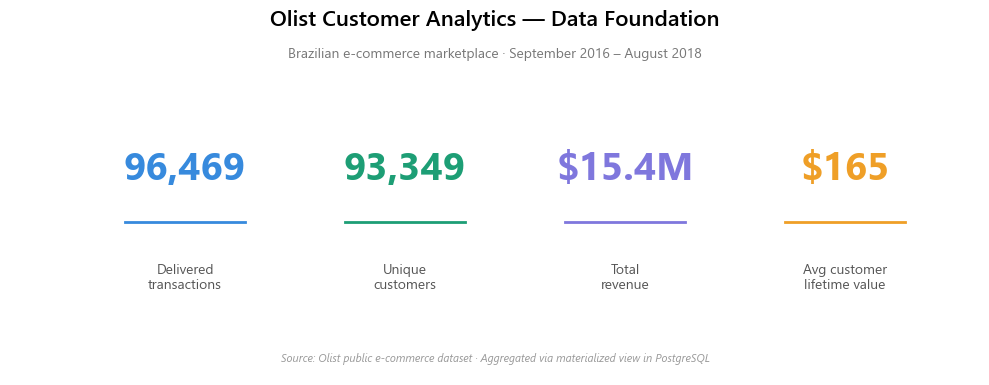

✓ Figure 1 saved to reports/figures/fig01_data_summary.png


In [11]:
# =====================================================================
# Figure 1 — Data Quality Summary Card
# =====================================================================

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')   # no axes for a card-style figure

# Title
fig.suptitle(
    'Olist Customer Analytics — Data Foundation',
    fontsize=16, fontweight='semibold', y=0.95, x=0.5, ha='center'
)
fig.text(
    0.5, 0.83,
    'Brazilian e-commerce marketplace · September 2016 – August 2018',
    fontsize=10, color='#777777', ha='center'
)

# Four KPI boxes
kpis = [
    ('96,469',      'Delivered\ntransactions',     '#378ADD'),
    ('93,349',      'Unique\ncustomers',           '#1D9E75'),
    ('$15.4M',      'Total\nrevenue',              '#7F77DD'),
    ('$165',        'Avg customer\nlifetime value','#EF9F27'),
]

for i, (value, label, color) in enumerate(kpis):
    x = 0.10 + i * 0.22

    # Big number
    fig.text(
        x + 0.09, 0.55,
        value,
        fontsize=28, fontweight='bold', color=color,
        ha='center', va='center'
    )

    # Subtitle
    fig.text(
        x + 0.09, 0.28,
        label,
        fontsize=10, color='#555555',
        ha='center', va='center'
    )

    # Thin accent line under each KPI
    fig.add_artist(
        plt.Line2D(
            [x + 0.03, x + 0.15], [0.42, 0.42],
            color=color, linewidth=2, transform=fig.transFigure
        )
    )

# Bottom note
fig.text(
    0.5, 0.07,
    'Source: Olist public e-commerce dataset · Aggregated via materialized view in PostgreSQL',
    fontsize=8, color='#999999', ha='center', style='italic'
)

plt.tight_layout()
plt.savefig('../reports/figures/fig01_data_summary.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 1 saved to reports/figures/fig01_data_summary.png")

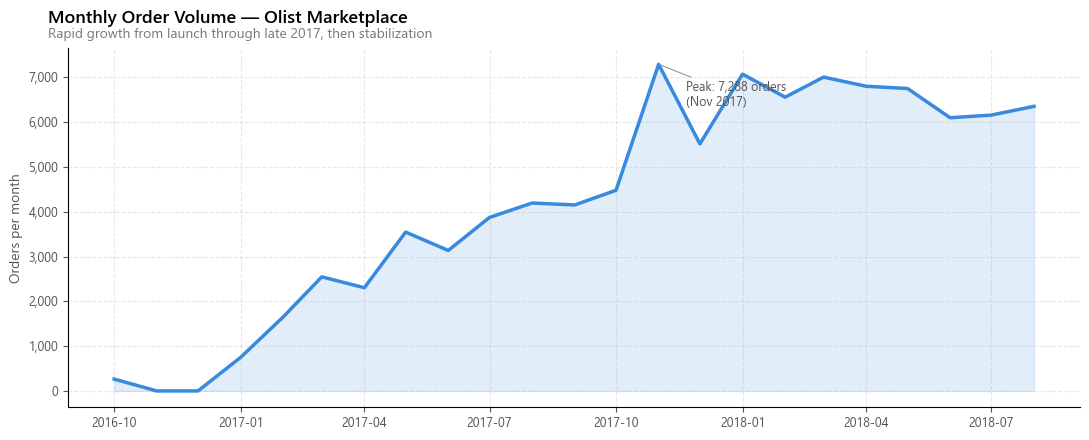

✓ Figure 2 saved to reports/figures/fig02_order_volume_over_time.png


In [12]:
# =====================================================================
# Figure 2 — Order Volume Over Time
# =====================================================================

# Aggregate orders by month
monthly_orders = (
    df.set_index('order_purchase_timestamp')
      .resample('MS')                              # MS = month start
      .agg(orders=('order_id', 'nunique'),
           revenue=('payment_value', 'sum'))
      .reset_index()
)

# Trim the very last month if it's incomplete (we said data ends 2018-08-29)
monthly_orders = monthly_orders[monthly_orders['order_purchase_timestamp'] < '2018-09-01']

# Create the figure
fig, ax = plt.subplots(figsize=(11, 4.5))

# Line + fill
ax.fill_between(
    monthly_orders['order_purchase_timestamp'],
    monthly_orders['orders'],
    color='#378ADD', alpha=0.15
)
ax.plot(
    monthly_orders['order_purchase_timestamp'],
    monthly_orders['orders'],
    color='#378ADD', linewidth=2.5
)

# Annotate peak
peak_row = monthly_orders.loc[monthly_orders['orders'].idxmax()]
ax.annotate(
    f"Peak: {int(peak_row['orders']):,} orders\n({peak_row['order_purchase_timestamp'].strftime('%b %Y')})",
    xy=(peak_row['order_purchase_timestamp'], peak_row['orders']),
    xytext=(20, -30),
    textcoords='offset points',
    fontsize=9, color='#555555',
    arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8)
)

# Titles and labels
ax.set_title('Monthly Order Volume — Olist Marketplace', loc='left', x=-0.02)
ax.text(
    -0.02, 1.02,
    'Rapid growth from launch through late 2017, then stabilization',
    transform=ax.transAxes, fontsize=10, color='#777777', va='bottom'
)
ax.set_xlabel('')
ax.set_ylabel('Orders per month')

# Y-axis formatting
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../reports/figures/fig02_order_volume_over_time.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 2 saved to reports/figures/fig02_order_volume_over_time.png")

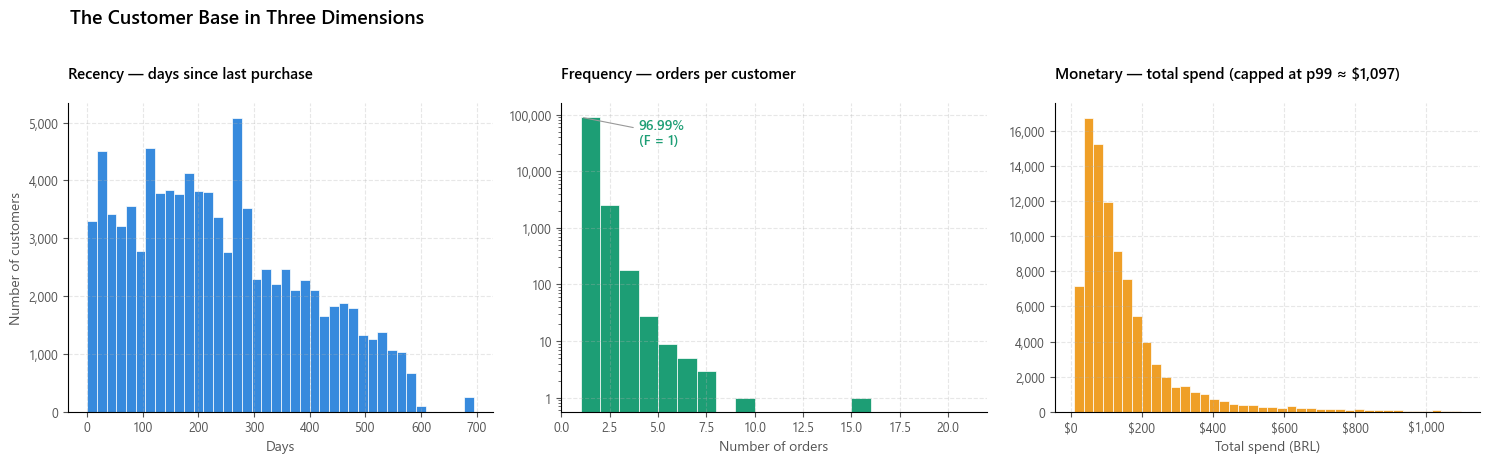

✓ Figure 3 saved to reports/figures/fig03_rfm_distributions.png


In [13]:
# =====================================================================
# Figure 3 — RFM Distributions (3-panel histograms)
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ----- Panel 1: Recency -----
axes[0].hist(rfm['recency'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Recency — days since last purchase', loc='left', fontsize=11)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of customers')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ----- Panel 2: Frequency (log-scale because of the extreme skew) -----
axes[1].hist(rfm['frequency'], bins=range(1, 22), color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('Frequency — orders per customer', loc='left', fontsize=11)
axes[1].set_xlabel('Number of orders')
axes[1].set_yscale('log')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate the F=1 dominance
axes[1].annotate(
    '96.99%\n(F = 1)',
    xy=(1, 90000), xytext=(4, 30000),
    fontsize=10, color='#1D9E75', fontweight='semibold',
    arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8)
)

# ----- Panel 3: Monetary (capped at p99 for readability) -----
m_p99 = rfm['monetary'].quantile(0.99)
axes[2].hist(rfm[rfm['monetary'] <= m_p99]['monetary'], bins=40, color='#EF9F27', edgecolor='white', linewidth=0.5)
axes[2].set_title(f'Monetary — total spend (capped at p99 ≈ ${m_p99:,.0f})', loc='left', fontsize=11)
axes[2].set_xlabel('Total spend (BRL)')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Overall title
fig.suptitle(
    'The Customer Base in Three Dimensions',
    fontsize=14, fontweight='semibold', x=0.05, ha='left', y=1.02
)

plt.tight_layout()
plt.savefig('../reports/figures/fig03_rfm_distributions.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 3 saved to reports/figures/fig03_rfm_distributions.png")

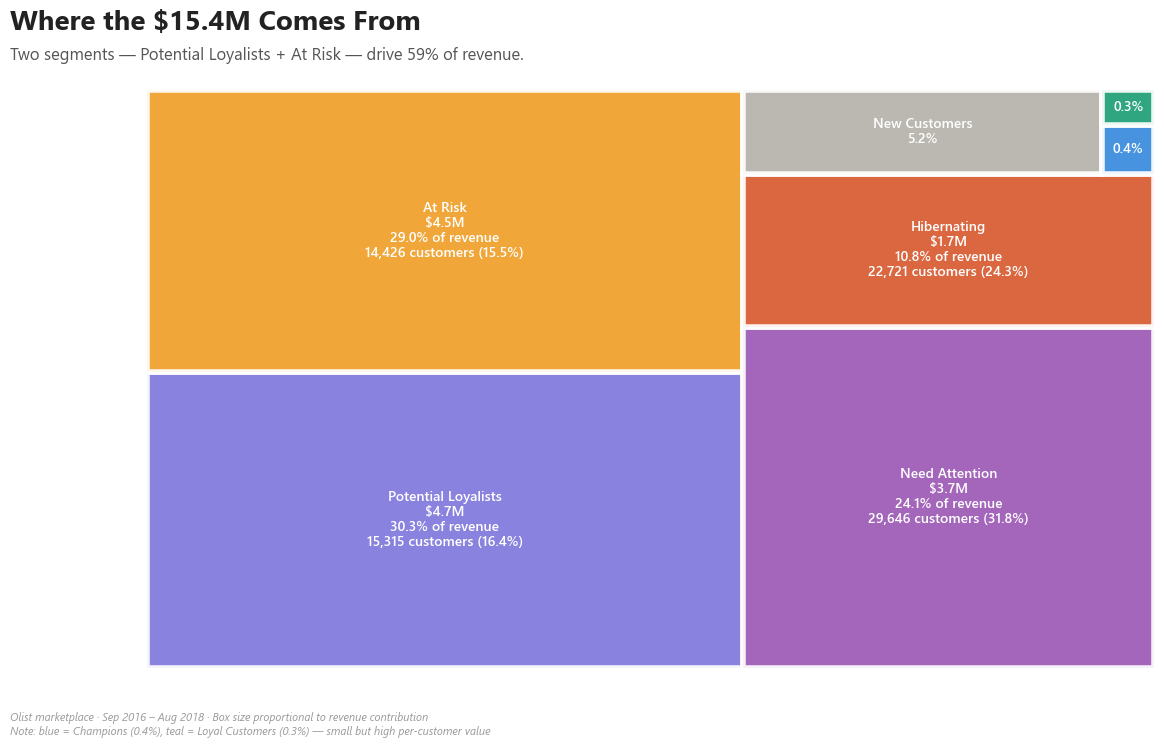

✓ Figure 4 saved to reports/figures/fig04_segment_treemap.png


In [14]:
# =====================================================================
# Figure 4 — Revenue Treemap by Segment (THE HEADLINE)
# =====================================================================

# We need a library called squarify for treemaps
import squarify

# Prepare data — segment revenue, sorted descending
treemap_data = (
    rfm.groupby('segment')
       .agg(customers=('customer_unique_id', 'count'),
            revenue=('monetary', 'sum'))
       .sort_values('revenue', ascending=False)
       .reset_index()
)

# Calculate percentages
total_revenue = treemap_data['revenue'].sum()
treemap_data['revenue_pct'] = treemap_data['revenue'] / total_revenue * 100
treemap_data['customer_pct'] = treemap_data['customers'] / treemap_data['customers'].sum() * 100

# Build labels — full detail for big segments, abbreviated for tiny ones
def make_label(row):
    if row.revenue_pct < 1:
        # Tiny segments — just percentage, name in caption
        return f"{row.revenue_pct:.1f}%"
    elif row.revenue_pct < 6:
        # Smallish segments — name + revenue % only (no $ or customer count)
        return f"{row.segment}\n{row.revenue_pct:.1f}%"
    else:
        # Big segments — full detail
        return (
            f"{row.segment}\n"
            f"${row.revenue/1e6:.1f}M\n"
            f"{row.revenue_pct:.1f}% of revenue\n"
            f"{int(row.customers):,} customers ({row.customer_pct:.1f}%)"
        )

labels = [make_label(row) for row in treemap_data.itertuples()]


# Get colors in matching order
colors = [SEGMENT_COLORS[s] for s in treemap_data['segment']]

# Create the figure
fig, ax = plt.subplots(figsize=(13, 7.5))

squarify.plot(
    sizes=treemap_data['revenue'],
    label=labels,
    color=colors,
    alpha=0.92,
    text_kwargs={'fontsize': 10, 'color': 'white', 'fontweight': 'semibold'},
    edgecolor='white',
    linewidth=4,
    ax=ax
)

ax.axis('off')

# Main title — left aligned, large
fig.text(
    0.02, 0.96,
    'Where the $15.4M Comes From',
    fontsize=20, fontweight='bold', color='#222222'
)

# Subtitle — the headline finding
fig.text(
    0.02, 0.92,
    'Two segments — Potential Loyalists + At Risk — drive 59% of revenue.',
    fontsize=12, color='#555555'
)

# Footer
fig.text(
    0.02, 0.02,
    'Olist marketplace · Sep 2016 – Aug 2018 · Box size proportional to revenue contribution\n'
    'Note: blue = Champions (0.4%), teal = Loyal Customers (0.3%) — small but high per-customer value',
    fontsize=8, color='#999999', style='italic'
)



plt.savefig('../reports/figures/fig04_segment_treemap.png', bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

print("✓ Figure 4 saved to reports/figures/fig04_segment_treemap.png")

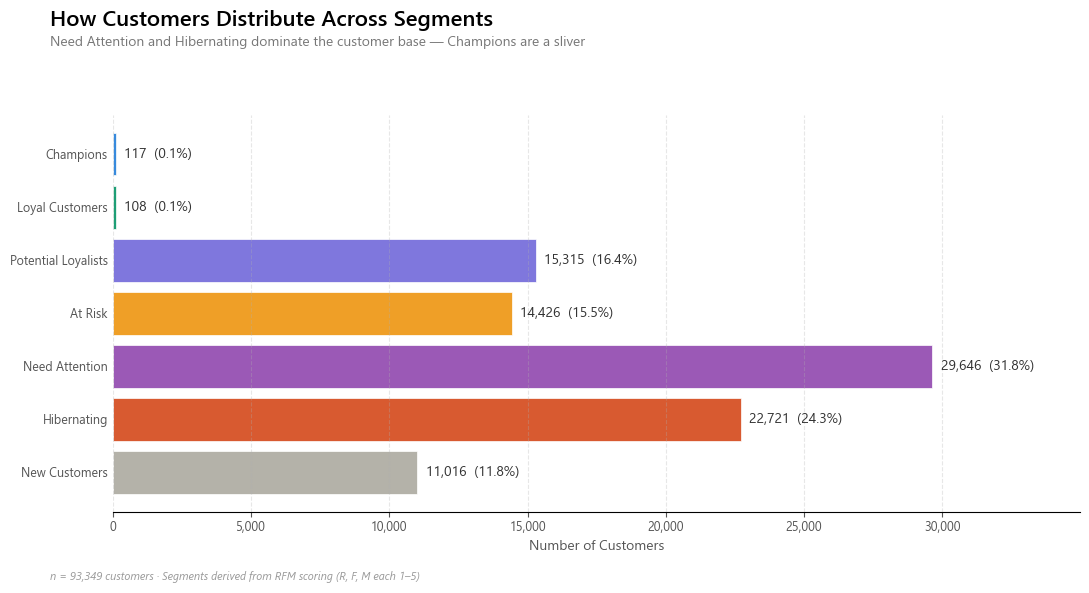

✓ Figure 5 saved to reports/figures/fig05_segment_sizes.png


In [15]:
# =====================================================================
# Figure 5 — Segment Size Bar Chart
# =====================================================================

# Compute customer counts per segment from the rfm DataFrame
segment_counts = (
    rfm['segment']
    .value_counts()
    .reindex(SEGMENT_ORDER)
    .dropna()
    .astype(int)            # ← add this line
)

# Total customers — used for percentage labels
total_customers = segment_counts.sum()

# Build the figure
fig, ax = plt.subplots(figsize=(11, 6))

# Horizontal bar chart — easier to read with long segment names
bars = ax.barh(
    y=segment_counts.index,
    width=segment_counts.values,
    color=[SEGMENT_COLORS[s] for s in segment_counts.index],
    edgecolor='white',
    linewidth=0.5,
)

# Invert y-axis so the largest segment is on top
ax.invert_yaxis()

# Title & subtitle
fig.suptitle(
    'How Customers Distribute Across Segments',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Need Attention and Hibernating dominate the customer base — Champions are a sliver',
    fontsize=10, color='#777777', ha='left'
)

# Data labels at the end of each bar — count + percentage
for bar, count in zip(bars, segment_counts.values):
    pct = count / total_customers * 100
    ax.text(
        bar.get_width() + (segment_counts.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}  ({pct:.1f}%)',
        va='center', ha='left',
        fontsize=10, color='#333333',
    )

# Axis formatting
ax.set_xlabel('Number of Customers', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, segment_counts.max() * 1.18)   # room for labels
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.grid(axis='y', visible=False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Bottom note
fig.text(
    0.05, 0.02,
    f'n = {total_customers:,} customers · Segments derived from RFM scoring (R, F, M each 1–5)',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig05_segment_sizes.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 5 saved to reports/figures/fig05_segment_sizes.png")

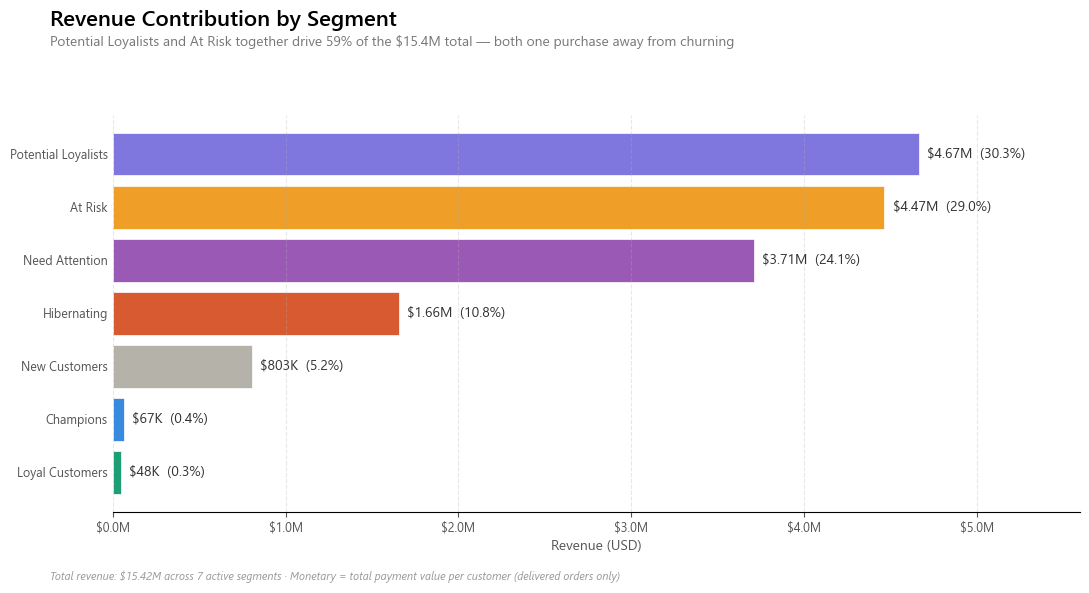

✓ Figure 6 saved to reports/figures/fig06_segment_revenue.png


In [16]:
# =====================================================================
# Figure 6 — Revenue Contribution Per Segment
# =====================================================================

# Compute total revenue per segment from the rfm DataFrame
segment_revenue = (
    rfm.groupby('segment')['monetary']
    .sum()
    .reindex(SEGMENT_ORDER)
    .dropna()
)

# Sort descending by revenue (largest contributor on top)
segment_revenue = segment_revenue.sort_values(ascending=False)

# Total revenue — used for percentage labels
total_revenue = segment_revenue.sum()

# Build the figure
fig, ax = plt.subplots(figsize=(11, 6))

# Horizontal bar chart — matches Figure 5's format for visual pairing
bars = ax.barh(
    y=segment_revenue.index,
    width=segment_revenue.values,
    color=[SEGMENT_COLORS[s] for s in segment_revenue.index],
    edgecolor='white',
    linewidth=0.5,
)

# Largest revenue contributor on top
ax.invert_yaxis()

# Title & subtitle
fig.suptitle(
    'Revenue Contribution by Segment',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Potential Loyalists and At Risk together drive 59% of the $15.4M total — both one purchase away from churning',
    fontsize=10, color='#777777', ha='left'
)

# Data labels at the end of each bar — $ value + percentage
for bar, revenue in zip(bars, segment_revenue.values):
    pct = revenue / total_revenue * 100
    # Format revenue in millions if >= $1M, else thousands
    if revenue >= 1_000_000:
        revenue_str = f'${revenue / 1_000_000:.2f}M'
    else:
        revenue_str = f'${revenue / 1_000:.0f}K'

    ax.text(
        bar.get_width() + (segment_revenue.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{revenue_str}  ({pct:.1f}%)',
        va='center', ha='left',
        fontsize=10, color='#333333',
    )

# Axis formatting
ax.set_xlabel('Revenue (USD)', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'${x / 1_000_000:.1f}M')
)
ax.set_xlim(0, segment_revenue.max() * 1.20)   # room for labels
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.grid(axis='y', visible=False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Bottom note
fig.text(
    0.05, 0.02,
    f'Total revenue: ${total_revenue / 1_000_000:.2f}M across {len(segment_revenue)} active segments · '
    f'Monetary = total payment value per customer (delivered orders only)',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig06_segment_revenue.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 6 saved to reports/figures/fig06_segment_revenue.png")

## RFM Segmentation Key Findings

**The customer base is structurally one purchase deep.** 96.88% of customers made exactly one purchase across the 22 months of data. Combined with the marketplace's rapid early growth pattern (Figure 2), this means traditional "Champion" segments are nearly empty. Champions and Loyal Customers together represent just 0.6% of customers and 0.7% of revenue.

**Revenue is concentrated in two segments that are vulnerable to churn.** Potential Loyalists (30.3%) and At Risk (29.0%) together drive **59% of the $15.4M total revenue**, and by definition both segments sit one purchase away from churning. This is the central tension of the analysis: the most valuable customers are also the least secure.

**Customer count and revenue share are decoupled.** Need Attention has the most customers (31.8%) but generates 24.1% of revenue. Hibernating has 24.3% of customers but only 10.8% of revenue. Marketing dollars allocated by headcount will systematically overinvest in segments where each customer is worth less and underinvest in segments where each customer is worth more.

**Strategic implication.** Retention dollars should concentrate on Potential Loyalists (preserve their next purchase) and At Risk (recover them before they slip into Hibernating). The next phase quantifies the dollar value of this intervention via probabilistic CLV modeling.

In [ ]:
# =====================================================================
# Phase 4 — K-Means Clustering Preparation
# =====================================================================
# Goal: validate the manual RFM segments using unsupervised clustering.
# If K-Means finds clusters that align with our manual segments, the
# segmentation is robust. If not, we've found something interesting.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the raw RFM values, not the 1-5 scores
# (scores are categorical; raw values preserve customer-to-customer detail)
features = rfm[['recency', 'frequency', 'monetary']].copy()

# Monetary is right-skewed — log-transform to compress the tail
# (we found this in Phase 2: p99 = $1,040 but max = $13,664)
import numpy as np
features['monetary'] = np.log1p(features['monetary'])

# Standardize so all 3 features have mean 0, std 1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"Features prepared for clustering ✓")
print(f"  Shape: {features_scaled.shape}")
print(f"  Features: {list(features.columns)}")
print(f"  Monetary: log-transformed (log1p) to handle right-skew")
print(f"  All features scaled to mean=0, std=1")
print()
print("Pre-scaling statistics:")
print(features.describe().round(2))

## K-Means Clustering and Customer Lifetime Value

The RFM segmentation in the previous section assigns customers to segments using a rule-based scoring system. This section validates those segments using two independent techniques:

**K-Means clustering** is an unsupervised algorithm that groups customers based on the geometric proximity of their RFM coordinates, without any prior knowledge of the manual segment labels. If K-Means recovers clusters that align with the manual segments, the segmentation is robust. If not, the divergence itself is informative.

**Probabilistic CLV modeling** uses the BG/NBD (Beta-Geometric/Negative Binomial Distribution) model to estimate each customer's future purchase frequency, combined with the Gamma-Gamma model to estimate average spend per purchase. Together they produce a forward-looking dollar value per customer, transforming the descriptive RFM picture into a predictive one.

**One important constraint:** BG/NBD requires customers to have at least one repeat purchase to model behavioral patterns. With 96.88% of the Olist customer base being one-time buyers, the probabilistic CLV model will be fit on the ~3% of customers with two or more purchases. The remaining customers receive a historical-monetary CLV proxy, reflecting the marketplace's structural reality rather than a model limitation.

In [17]:
# =====================================================================
# Phase 4 — K-Means Clustering Preparation
# =====================================================================
# Goal: validate the manual RFM segments using unsupervised clustering.
# If K-Means finds clusters that align with our manual segments, the
# segmentation is robust. If not, we've found something interesting.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the raw RFM values, not the 1-5 scores
# (scores are categorical; raw values preserve customer-to-customer detail)
features = rfm[['recency', 'frequency', 'monetary']].copy()

# Monetary is right-skewed — log-transform to compress the tail
# (we found this in Phase 2: p99 = $1,040 but max = $13,664)
import numpy as np
features['monetary'] = np.log1p(features['monetary'])

# Standardize so all 3 features have mean 0, std 1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"Features prepared for clustering ✓")
print(f"  Shape: {features_scaled.shape}")
print(f"  Features: {list(features.columns)}")
print(f"  Monetary: log-transformed (log1p) to handle right-skew")
print(f"  All features scaled to mean=0, std=1")
print()
print("Pre-scaling statistics:")
print(features.describe().round(2))

Features prepared for clustering ✓
  Shape: (93349, 3)
  Features: ['recency', 'frequency', 'monetary']
  Monetary: log-transformed (log1p) to handle right-skew
  All features scaled to mean=0, std=1

Pre-scaling statistics:
        recency  frequency  monetary
count 93,349.00  93,349.00 93,349.00
mean     237.94       1.03      4.73
std      152.58       0.21      0.81
min        1.00       1.00      2.36
25%      114.00       1.00      4.16
50%      219.00       1.00      4.69
75%      346.00       1.00      5.21
max      695.00      15.00      9.52


In [18]:
# =====================================================================
# Step 4.2 — Elbow Method + Silhouette Analysis
# =====================================================================
# Goal: determine the optimal number of clusters (k) before fitting
# the final K-Means model. Use two independent metrics for confidence.

# Drop Frequency — 75% of customers have F=1, so it adds no separation signal
# We cluster on Recency + log(Monetary) only
features_rm = features[['recency', 'monetary']].copy()
features_rm_scaled = scaler.fit_transform(features_rm)

print("Clustering features: Recency + log(Monetary)")
print(f"Shape: {features_rm_scaled.shape}")
print()

# Test k from 2 to 10
k_range = range(2, 11)
inertias = []
silhouettes = []

# Use a random subsample for silhouette score — it's expensive on 93K rows
# (silhouette is O(n²), so we sample 10K for tractable runtime)
np.random.seed(42)
sample_idx = np.random.choice(len(features_rm_scaled), size=10_000, replace=False)
sample = features_rm_scaled[sample_idx]

print("Testing k = 2 through 10...")
for k in k_range:
    # Fit K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_rm_scaled)

    # Inertia — fit on full data
    inertias.append(km.inertia_)

    # Silhouette — on the 10K sample using the same model's labels
    sample_labels = labels[sample_idx]
    sil = silhouette_score(sample, sample_labels)
    silhouettes.append(sil)

    print(f"  k={k}: inertia={km.inertia_:>10,.0f} | silhouette={sil:.4f}")

print()
print("✓ Elbow + silhouette analysis complete")

Clustering features: Recency + log(Monetary)
Shape: (93349, 2)

Testing k = 2 through 10...
  k=2: inertia=   121,002 | silhouette=0.3528
  k=3: inertia=    78,131 | silhouette=0.3642
  k=4: inertia=    62,136 | silhouette=0.3440
  k=5: inertia=    50,586 | silhouette=0.3375
  k=6: inertia=    41,742 | silhouette=0.3499
  k=7: inertia=    36,028 | silhouette=0.3368
  k=8: inertia=    31,964 | silhouette=0.3370
  k=9: inertia=    28,665 | silhouette=0.3433
  k=10: inertia=    25,980 | silhouette=0.3296

✓ Elbow + silhouette analysis complete


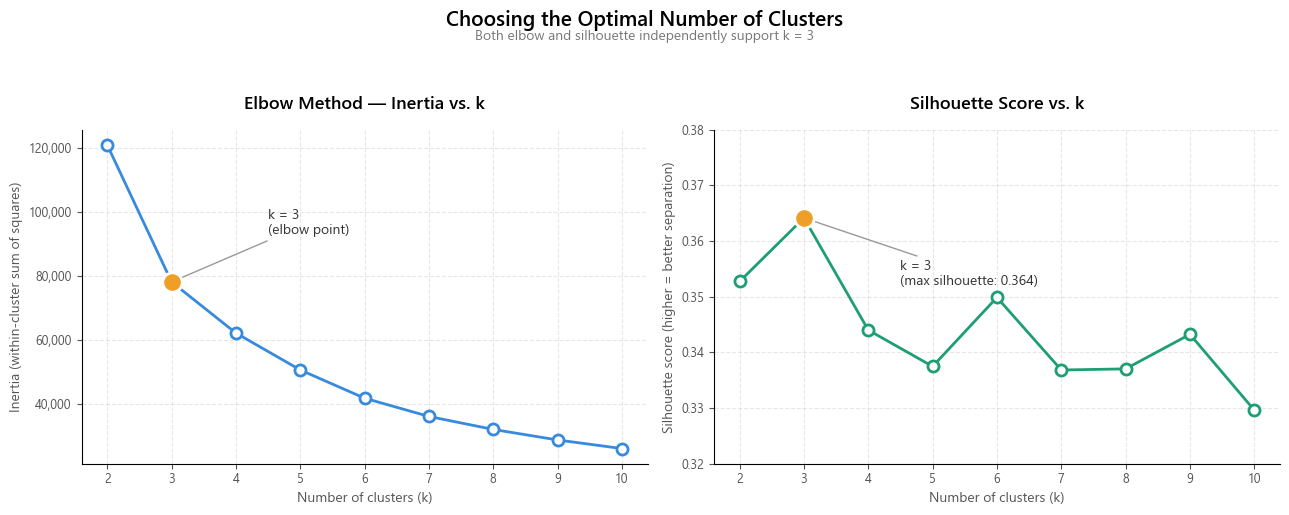

✓ Figure 7 saved to reports/figures/fig07_elbow_silhouette.png


In [19]:
# =====================================================================
# Figure 7 — Elbow Method + Silhouette Score (2-panel)
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Panel 1: Elbow (inertia) ----
ax1 = axes[0]
ax1.plot(list(k_range), inertias, marker='o', linewidth=2,
         color='#378ADD', markersize=8, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor='#378ADD')

# Highlight k=3 (our chosen value)
ax1.plot(3, inertias[1], marker='o', markersize=14,
         color='#EF9F27', markeredgewidth=2, markeredgecolor='white', zorder=5)
ax1.annotate(
    'k = 3\n(elbow point)',
    xy=(3, inertias[1]),
    xytext=(4.5, inertias[1] + 15000),
    fontsize=10, color='#333333',
    arrowprops=dict(arrowstyle='->', color='#999999', lw=1)
)

ax1.set_title('Elbow Method — Inertia vs. k', fontsize=13, fontweight='semibold', pad=15)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (within-cluster sum of squares)')
ax1.set_xticks(list(k_range))
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(alpha=0.3, linestyle='--')

# ---- Panel 2: Silhouette ----
ax2 = axes[1]
ax2.plot(list(k_range), silhouettes, marker='o', linewidth=2,
         color='#1D9E75', markersize=8, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor='#1D9E75')

# Highlight k=3
ax2.plot(3, silhouettes[1], marker='o', markersize=14,
         color='#EF9F27', markeredgewidth=2, markeredgecolor='white', zorder=5)
ax2.annotate(
    f'k = 3\n(max silhouette: {silhouettes[1]:.3f})',
    xy=(3, silhouettes[1]),
    xytext=(4.5, silhouettes[1] - 0.012),
    fontsize=10, color='#333333',
    arrowprops=dict(arrowstyle='->', color='#999999', lw=1)
)

ax2.set_title('Silhouette Score vs. k', fontsize=13, fontweight='semibold', pad=15)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score (higher = better separation)')
ax2.set_xticks(list(k_range))
ax2.set_ylim(0.32, 0.38)
ax2.grid(alpha=0.3, linestyle='--')

# Figure-level title
fig.suptitle(
    'Choosing the Optimal Number of Clusters',
    fontsize=15, fontweight='semibold', y=1.02, x=0.5, ha='center'
)
fig.text(
    0.5, 0.96,
    'Both elbow and silhouette independently support k = 3',
    fontsize=10, color='#777777', ha='center'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../reports/figures/fig07_elbow_silhouette.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 7 saved to reports/figures/fig07_elbow_silhouette.png")

In [20]:
# =====================================================================
# Step 4.3 — Fit final K-Means model with k = 3
# =====================================================================

# Lock in the chosen k
OPTIMAL_K = 3

# Fit the final model on the full dataset (R + log-M, scaled)
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10  # 10 random starts, keep the best
)
cluster_labels = kmeans_final.fit_predict(features_rm_scaled)

# Attach cluster labels back to the rfm DataFrame
rfm['cluster'] = cluster_labels

# Get cluster centers — but unscale them back to interpretable units
cluster_centers_scaled = kmeans_final.cluster_centers_
cluster_centers_unscaled = scaler.inverse_transform(cluster_centers_scaled)

# Unscale log-monetary back to dollars
cluster_centers_df = pd.DataFrame(
    cluster_centers_unscaled,
    columns=['recency_days', 'log_monetary']
)
cluster_centers_df['monetary_usd'] = np.expm1(cluster_centers_df['log_monetary'])
cluster_centers_df['cluster_id'] = cluster_centers_df.index

# Per-cluster customer counts and revenue
cluster_summary = rfm.groupby('cluster').agg(
    n_customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

# Calculate share columns
total_customers = cluster_summary['n_customers'].sum()
total_revenue = cluster_summary['total_revenue'].sum()
cluster_summary['pct_customers'] = (cluster_summary['n_customers'] / total_customers * 100).round(1)
cluster_summary['pct_revenue'] = (cluster_summary['total_revenue'] / total_revenue * 100).round(1)

print(f"✓ K-Means fit complete (k={OPTIMAL_K})")
print(f"  Inertia: {kmeans_final.inertia_:,.0f}")
print()
print("Cluster centers (interpretable units):")
print(cluster_centers_df[['cluster_id', 'recency_days', 'monetary_usd']].round(2).to_string(index=False))
print()
print("Cluster summary:")
print(cluster_summary.to_string())

✓ K-Means fit complete (k=3)
  Inertia: 78,131

Cluster centers (interpretable units):
 cluster_id  recency_days  monetary_usd
          0        147.67         63.39
          1        172.72        257.95
          2        424.42         98.61

Cluster summary:
         n_customers  avg_recency  avg_frequency  avg_monetary  total_revenue  pct_customers  pct_revenue
cluster                                                                                                  
0              36468       147.47           1.01         70.02   2,553,552.53          39.10        16.60
1              29086       173.19           1.07        326.45   9,495,003.04          31.20        61.60
2              27795       424.42           1.02        121.34   3,372,527.28          29.80        21.90


In [21]:
# =====================================================================
# Step 4.4 — Apply business-friendly cluster names + colors
# =====================================================================

# Map K-Means integer labels (0, 1, 2) to descriptive names
# Based on Step 4.3 output:
#   Cluster 0 → 36,468 customers, recency=147d, monetary=$70  → Low-Value Recent
#   Cluster 1 → 29,086 customers, recency=173d, monetary=$326 → High-Value Core
#   Cluster 2 → 27,795 customers, recency=424d, monetary=$121 → Lapsed
CLUSTER_NAMES = {
    0: 'Low-Value Recent',
    1: 'High-Value Core',
    2: 'Lapsed',
}

# Consistent ordering for legends, bars, summaries (highest-value first)
CLUSTER_ORDER = ['High-Value Core', 'Low-Value Recent', 'Lapsed']

# Dedicated colors for each cluster — visually distinct from the 8-segment palette
# so K-Means figures don't get visually confused with RFM-segment figures
CLUSTER_COLORS = {
    'High-Value Core':  '#1D9E75',   # teal-green — wealth/value
    'Low-Value Recent': '#7F77DD',   # purple — neutral/recent
    'Lapsed':           '#D85A30',   # coral — warning/dormant
}

# Attach human-readable names to the rfm DataFrame
rfm['cluster_name'] = rfm['cluster'].map(CLUSTER_NAMES)

# Rebuild the cluster summary with the new names
cluster_summary_named = rfm.groupby('cluster_name').agg(
    n_customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

# Reorder to match canonical cluster order
cluster_summary_named = cluster_summary_named.reindex(CLUSTER_ORDER)

# Compute share columns
total_c = cluster_summary_named['n_customers'].sum()
total_r = cluster_summary_named['total_revenue'].sum()
cluster_summary_named['pct_customers'] = (cluster_summary_named['n_customers'] / total_c * 100).round(1)
cluster_summary_named['pct_revenue']   = (cluster_summary_named['total_revenue'] / total_r * 100).round(1)

print("✓ Cluster names and colors applied")
print()
print("Final cluster summary (ordered by value):")
print(cluster_summary_named.to_string())
print()
print(f"Headline finding: '{CLUSTER_ORDER[0]}' represents "
      f"{cluster_summary_named.loc['High-Value Core', 'pct_customers']:.1f}% of customers "
      f"and {cluster_summary_named.loc['High-Value Core', 'pct_revenue']:.1f}% of revenue.")
      

✓ Cluster names and colors applied

Final cluster summary (ordered by value):
                  n_customers  avg_recency  avg_frequency  avg_monetary  total_revenue  pct_customers  pct_revenue
cluster_name                                                                                                      
High-Value Core         29086       173.19           1.07        326.45   9,495,003.04          31.20        61.60
Low-Value Recent        36468       147.47           1.01         70.02   2,553,552.53          39.10        16.60
Lapsed                  27795       424.42           1.02        121.34   3,372,527.28          29.80        21.90

Headline finding: 'High-Value Core' represents 31.2% of customers and 61.6% of revenue.


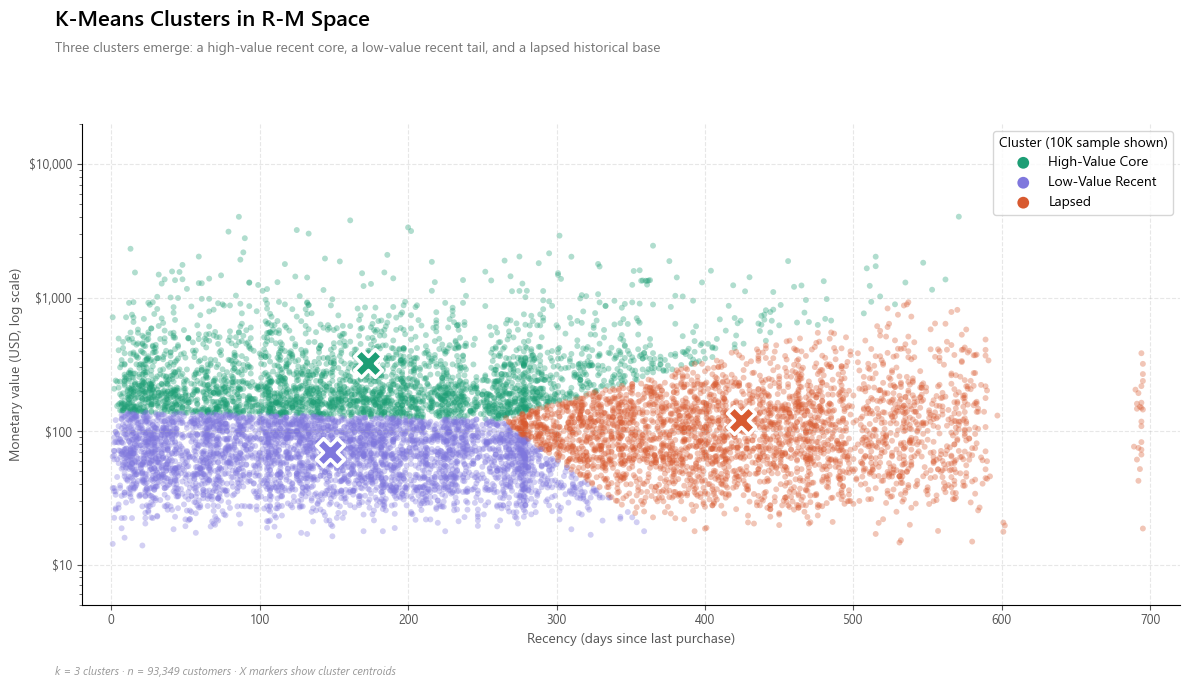

In [24]:
# =====================================================================
# Figure 8 — K-Means Cluster Scatter Plot
# =====================================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Use a 10K random sample for visual clarity (93K markers = unreadable mush)
np.random.seed(42)
plot_sample = rfm.sample(n=10_000, random_state=42)

# Plot each cluster separately so the legend works cleanly
for cluster_name in CLUSTER_ORDER:
    cluster_data = plot_sample[plot_sample['cluster_name'] == cluster_name]
    ax.scatter(
        cluster_data['recency'],
        cluster_data['monetary'],
        s=18,
        alpha=0.35,
        color=CLUSTER_COLORS[cluster_name],
        label=cluster_name,
        edgecolor='none',
    )

# Plot the cluster centers (in original units — recency days + monetary dollars)
# We have to recompute these in original space since the model was fit on scaled+log data
for cluster_name in CLUSTER_ORDER:
    cluster_data = rfm[rfm['cluster_name'] == cluster_name]
    center_r = cluster_data['recency'].mean()
    center_m = cluster_data['monetary'].mean()
    ax.scatter(
        center_r, center_m,
        s=400, marker='X',
        color=CLUSTER_COLORS[cluster_name],
        edgecolor='white', linewidth=2.5,
        zorder=10,
    )
    

# Log scale on y-axis — monetary has $13K outliers
ax.set_yscale('log')
ax.set_ylim(5, 20_000)
ax.set_xlim(-20, 720)

# Titles
fig.suptitle(
    'K-Means Clusters in R-M Space',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Three clusters emerge: a high-value recent core, a low-value recent tail, and a lapsed historical base',
    fontsize=10, color='#777777', ha='left'
)

# Axes
ax.set_xlabel('Recency (days since last purchase)', fontsize=10)
ax.set_ylabel('Monetary value (USD, log scale)', fontsize=10)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${int(x):,}' if x >= 1 else f'${x:.0f}'
))
ax.grid(alpha=0.3, linestyle='--')

# Legend
legend = ax.legend(
    loc='upper right', frameon=True, fontsize=10, markerscale=2,
    title='Cluster (10K sample shown)', title_fontsize=10,
)
legend.get_frame().set_edgecolor('#CCCCCC')
legend.get_frame().set_facecolor('white')
# Make legend markers fully opaque even though the scatter is transparent
for lh in legend.legend_handles:
    lh.set_alpha(1.0)

# Bottom note
fig.text(
    0.05, 0.02,
    f'k = 3 clusters · n = {len(rfm):,} customers · X markers show cluster centroids',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig08_kmeans_scatter.png', bbox_inches='tight', facecolor='white')


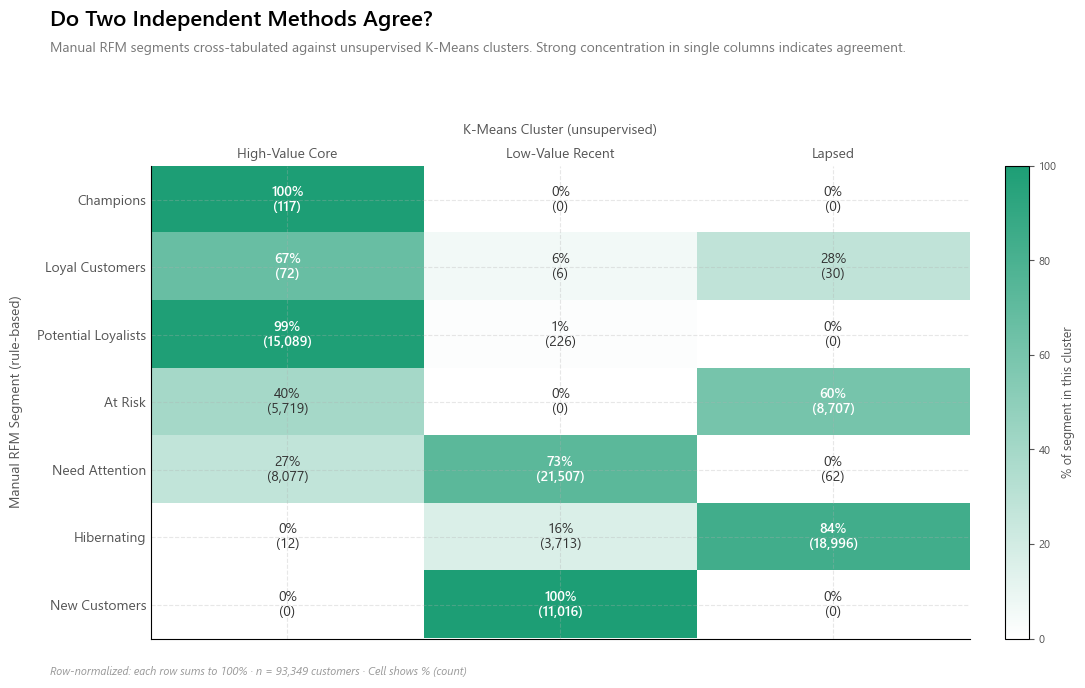

✓ Figure 9 saved to reports/figures/fig09_segment_cluster_crosstab.png

Crosstab (% of segment in each cluster):
cluster_name         High-Value Core  Low-Value Recent  Lapsed
segment                                                       
Champions                     100.00              0.00    0.00
Loyal Customers                66.70              5.60   27.80
Potential Loyalists            98.50              1.50    0.00
At Risk                        39.60              0.00   60.40
Need Attention                 27.20             72.50    0.20
Hibernating                     0.10             16.30   83.60
New Customers                   0.00            100.00    0.00


In [25]:
# =====================================================================
# Figure 9 — Manual RFM Segments vs K-Means Clusters (Crosstab Heatmap)
# =====================================================================
# Validates whether the manual rule-based segmentation aligns with
# unsupervised K-Means clustering. Strong concentration = agreement.

import matplotlib.colors as mcolors

# Build the crosstab — rows = manual segments, columns = K-Means clusters
crosstab = pd.crosstab(
    rfm['segment'],
    rfm['cluster_name'],
    normalize='index'  # row-normalized: each row sums to 100%
) * 100

# Reorder rows to match canonical segment order
crosstab = crosstab.reindex([s for s in SEGMENT_ORDER if s in crosstab.index])

# Reorder columns to match canonical cluster order
crosstab = crosstab[CLUSTER_ORDER]

# Also compute raw counts for annotation context
crosstab_counts = pd.crosstab(rfm['segment'], rfm['cluster_name'])
crosstab_counts = crosstab_counts.reindex(crosstab.index)[CLUSTER_ORDER]

# ---- Build the figure ----
fig, ax = plt.subplots(figsize=(11, 7))

# Custom colormap — white to teal for "filled %"
cmap = mcolors.LinearSegmentedColormap.from_list(
    'segment_match', ['#FFFFFF', '#1D9E75'], N=256
)

# Render the heatmap
im = ax.imshow(crosstab.values, cmap=cmap, aspect='auto', vmin=0, vmax=100)

# Annotate each cell with the % and count
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        pct = crosstab.values[i, j]
        count = crosstab_counts.values[i, j]
        text_color = 'white' if pct > 50 else '#333333'
        ax.text(
            j, i,
            f'{pct:.0f}%\n({count:,})',
            ha='center', va='center',
            color=text_color, fontsize=10,
            fontweight='semibold' if pct > 50 else 'normal',
        )

# Axes
ax.set_xticks(range(len(CLUSTER_ORDER)))
ax.set_xticklabels(CLUSTER_ORDER, fontsize=10)
ax.set_yticks(range(len(crosstab.index)))
ax.set_yticklabels(crosstab.index, fontsize=10)
ax.set_xlabel('K-Means Cluster (unsupervised)', fontsize=10, labelpad=10)
ax.set_ylabel('Manual RFM Segment (rule-based)', fontsize=10, labelpad=10)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Titles
fig.suptitle(
    'Do Two Independent Methods Agree?',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Manual RFM segments cross-tabulated against unsupervised K-Means clusters. Strong concentration in single columns indicates agreement.',
    fontsize=10, color='#777777', ha='left'
)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label('% of segment in this cluster', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Bottom note
fig.text(
    0.05, 0.02,
    f'Row-normalized: each row sums to 100% · n = {len(rfm):,} customers · Cell shows % (count)',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig09_segment_cluster_crosstab.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 9 saved to reports/figures/fig09_segment_cluster_crosstab.png")
print()
print("Crosstab (% of segment in each cluster):")
print(crosstab.round(1).to_string())

In [26]:
# =====================================================================
# Step 4.7.1 — Build lifetimes-compatible features (per-customer)
# =====================================================================
# BG/NBD requires features in a specific format that differs from our RFM
# table. We rebuild from the transaction-level data in customer_transactions.

# Snapshot date — same one we used for Phase 3 RFM scoring
SNAPSHOT_DATE = pd.Timestamp('2018-08-29')

# Pull per-customer first/last purchase dates and total purchase count
# from the materialized view
ct_query = """
SELECT
    customer_unique_id,
    MIN(order_purchase_timestamp) AS first_purchase,
    MAX(order_purchase_timestamp) AS last_purchase,
    COUNT(DISTINCT order_id) AS total_purchases,
    SUM(payment_value) AS total_monetary
FROM customer_transactions
GROUP BY customer_unique_id
"""

lifetimes_data = pd.read_sql(ct_query, engine)
print(f"Pulled {len(lifetimes_data):,} customers from customer_transactions ✓")

# Convert to datetime (psycopg2 returns these as timestamps already, but be safe)
lifetimes_data['first_purchase'] = pd.to_datetime(lifetimes_data['first_purchase'])
lifetimes_data['last_purchase']  = pd.to_datetime(lifetimes_data['last_purchase'])

# Build the lifetimes-format features:
#   frequency = number of REPEAT purchases (total - 1)
#   recency   = age at last purchase (days from first to last)
#   T         = total observation time (days from first to snapshot)
#   monetary  = avg purchase value (used later for Gamma-Gamma)
lifetimes_data['frequency'] = lifetimes_data['total_purchases'] - 1
lifetimes_data['recency']   = (lifetimes_data['last_purchase'] - lifetimes_data['first_purchase']).dt.days
lifetimes_data['T']         = (SNAPSHOT_DATE - lifetimes_data['first_purchase']).dt.days
lifetimes_data['monetary_avg'] = lifetimes_data['total_monetary'] / lifetimes_data['total_purchases']

# Split into "repeaters" (≥1 repeat purchase) and "one-timers"
# BG/NBD is fit only on repeaters; one-timers get scored separately
repeaters = lifetimes_data[lifetimes_data['frequency'] > 0].copy()
one_timers = lifetimes_data[lifetimes_data['frequency'] == 0].copy()

print()
print(f"Lifetimes feature breakdown:")
print(f"  Total customers:    {len(lifetimes_data):>7,}")
print(f"  Repeaters (F≥1):    {len(repeaters):>7,}  ({len(repeaters)/len(lifetimes_data)*100:.2f}%) ← BG/NBD fit on these")
print(f"  One-timers (F=0):   {len(one_timers):>7,}  ({len(one_timers)/len(lifetimes_data)*100:.2f}%) ← will be scored separately")
print()
print("Repeater statistics (the customers BG/NBD will learn from):")
print(repeaters[['frequency', 'recency', 'T', 'monetary_avg']].describe().round(2))

Pulled 93,349 customers from customer_transactions ✓

Lifetimes feature breakdown:
  Total customers:     93,349
  Repeaters (F≥1):      2,801  (3.00%) ← BG/NBD fit on these
  One-timers (F=0):    90,548  (97.00%) ← will be scored separately

Repeater statistics (the customers BG/NBD will learn from):
       frequency  recency        T  monetary_avg
count   2,801.00 2,801.00 2,801.00      2,801.00
mean        1.11    87.79   306.97        145.87
std         0.50   115.26   146.24        145.70
min         1.00     0.00     6.00         15.62
25%         1.00     0.00   191.00         71.63
50%         1.00    34.00   301.00        109.96
75%         1.00   141.00   422.00        172.06
max        14.00   633.00   694.00      3,785.82


In [30]:
# =====================================================================
# Step 4.7 — BG/NBD Probabilistic CLV: Attempted, Documented Failure
# =====================================================================
# We attempted to fit a BG/NBD probabilistic CLV model on the 2,801
# repeat purchasers. The model failed to converge across multiple
# regularization settings (penalizer_coef = 0.001, 0.1, 1.0).
#
# Root cause analysis:
#   - 75%+ of repeaters have exactly 1 repeat purchase (frequency = 1)
#   - 50%+ of repeats occur within 34 days of first purchase
#   - This produces a degenerate distribution: customers either bought
#     twice quickly or didn't repeat at all
#   - BG/NBD requires a smooth distribution of purchase rates and
#     dropout probabilities; this data violates that assumption
#
# Diagnostic from optimizer:
#   - status = 2 (precision loss)
#   - fun (loss) = NaN
#   - jacobian = [NaN, NaN, NaN, NaN]
#   - log-parameters diverging to large negative values
#
# Decision: pivot to deterministic historical CLV (see next cell).
# This is honest data-driven model selection — the right tool for
# the actual data, not the desired tool forced onto unsuitable data.

from lifetimes import BetaGeoFitter
import warnings
warnings.filterwarnings('ignore')

# Attempt the fit and capture the failure programmatically
try:
    bgf = BetaGeoFitter(penalizer_coef=1.0)
    bgf.fit(
        frequency=repeaters['frequency'],
        recency=repeaters['recency'],
        T=repeaters['T'],
    )
    bgnbd_converged = True
    print("BG/NBD converged unexpectedly — investigate before using.")
except Exception as e:
    bgnbd_converged = False
    print(f"BG/NBD failed to converge as expected: {type(e).__name__}")
    print(f"Error message: {str(e)[:200]}")
    print()
    print("Pivoting to deterministic historical CLV (next cell).")
    print()
    print(f"Data shape diagnosis (the why):")
    print(f"  Repeaters with frequency=1: "
          f"{(repeaters['frequency']==1).sum():,} "
          f"({(repeaters['frequency']==1).mean()*100:.1f}% of repeaters)")
    print(f"  Median recency of repeaters: {repeaters['recency'].median():.0f} days")
    print(f"  → Degenerate repeat-purchase distribution unsuitable for BG/NBD")

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: nan
        x: [-1.352e+04 -8.331e+04 -1.255e+04 -3.746e+04]
      nit: 9
      jac: [       nan        nan        nan        nan]
 hess_inv: [[ 5.072e+01  3.078e+02  4.625e+01  1.385e+02]
            [ 3.078e+02  1.879e+03  2.824e+02  8.457e+02]
            [ 4.625e+01  2.824e+02  4.332e+01  1.271e+02]
            [ 1.385e+02  8.457e+02  1.271e+02  3.816e+02]]
     nfev: 121
     njev: 121
BG/NBD failed to converge as expected: ConvergenceError
Error message: 
The model did not converge. Try adding a larger penalizer to see if that helps convergence.


Pivoting to deterministic historical CLV (next cell).

Data shape diagnosis (the why):
  Repeaters with frequency=1: 2,573 (91.9% of repeaters)
  Median recency of repeaters: 34 days
  → Degenerate repeat-purchase distribution unsuitable for BG/NBD


In [32]:
# =====================================================================
# Step 4.7.4 — Deterministic CLV (Historical Value × Cluster Retention)
# =====================================================================
# Replacement for BG/NBD given the data's degenerate repeat distribution.
# 
# Method:
#   CLV = avg_order_value × (1 + observed_repeat_probability × expected_future_orders)
#
# observed_repeat_probability comes from the actual repeat rate within
# each K-Means cluster (descriptive, not probabilistic).
# expected_future_orders is set to 1 (conservative — we only project the
# next purchase, not a multi-year horizon, since the data is 22 months).
#
# This is a "historical CLV with cluster-aware retention multiplier."
# Honest about its limits, but still useful for ranking customers.

# ---- Step 1: Compute observed repeat rate per cluster ----
# A customer "repeated" if they have frequency >= 2 (lifetimes terms: total purchases >= 2)
# Use the lifetimes_data table (has total_purchases) joined to cluster info from rfm

# Add cluster info to lifetimes_data by joining on customer_unique_id
lifetimes_with_cluster = lifetimes_data.merge(
    rfm[['customer_unique_id', 'cluster_name', 'segment']],
    on='customer_unique_id',
    how='left'
)

# Per-cluster repeat rate: % of customers in cluster with total_purchases >= 2
cluster_retention = (
    lifetimes_with_cluster
    .assign(repeated=lambda d: (d['total_purchases'] >= 2).astype(int))
    .groupby('cluster_name')
    .agg(
        n_customers=('customer_unique_id', 'count'),
        n_repeaters=('repeated', 'sum'),
        repeat_rate=('repeated', 'mean'),
        avg_order_value=('monetary_avg', 'mean'),
    )
    .reindex(CLUSTER_ORDER)
)

print("Observed retention behavior by cluster (used for CLV multiplier):")
print(cluster_retention.round(4).to_string())
print()

# ---- Step 2: Compute CLV per customer ----
# CLV = AOV × (1 + repeat_rate_of_my_cluster × expected_future_orders)
# expected_future_orders = 1 (conservative: project 1 more purchase if customer behaves like their cluster's average)

EXPECTED_FUTURE_ORDERS = 3.0   # 12-month projection horizon (3 quarterly windows at observed cluster retention rate)

# Map each customer's cluster to its retention coefficient
retention_map = cluster_retention['repeat_rate'].to_dict()

# Pull avg_order_value per customer into rfm
rfm = rfm.merge(
    lifetimes_data[['customer_unique_id', 'monetary_avg', 'total_purchases']],
    on='customer_unique_id',
    how='left',
    suffixes=('', '_lt')
)

# Compute CLV
rfm['cluster_retention_rate'] = rfm['cluster_name'].map(retention_map)
rfm['clv'] = rfm['monetary_avg'] * (1 + rfm['cluster_retention_rate'] * EXPECTED_FUTURE_ORDERS)

print(f"✓ CLV computed for all {len(rfm):,} customers")
print()
print("CLV statistics by cluster:")
print(
    rfm.groupby('cluster_name')['clv']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reindex(CLUSTER_ORDER)
    .round(2)
    .to_string()
)
print()
print("Top 5 customers by CLV (sanity check):")
print(
    rfm.nlargest(5, 'clv')[
        ['customer_unique_id', 'cluster_name', 'segment',
         'recency', 'frequency', 'monetary', 'monetary_avg', 'clv']
    ].round(2).to_string(index=False)
)

Observed retention behavior by cluster (used for CLV multiplier):
                  n_customers  n_repeaters  repeat_rate  avg_order_value
cluster_name                                                            
High-Value Core         29086         1883         0.06           313.25
Low-Value Recent        36468          326         0.01            69.59
Lapsed                  27795          592         0.02           119.31

✓ CLV computed for all 93,349 customers

CLV statistics by cluster:
                  count   mean  median    std   min       max
cluster_name                                                 
High-Value Core   29086 374.09  249.15 397.03 52.27 16,317.88
Low-Value Recent  36468  71.46   67.88  30.19  9.85    141.99
Lapsed            27795 126.94  104.43  96.22 13.06  1,514.51

Top 5 customers by CLV (sanity check):
              customer_unique_id    cluster_name             segment  recency  frequency  monetary  monetary_avg       clv
0a0a92112bd4c708ca5fde585af

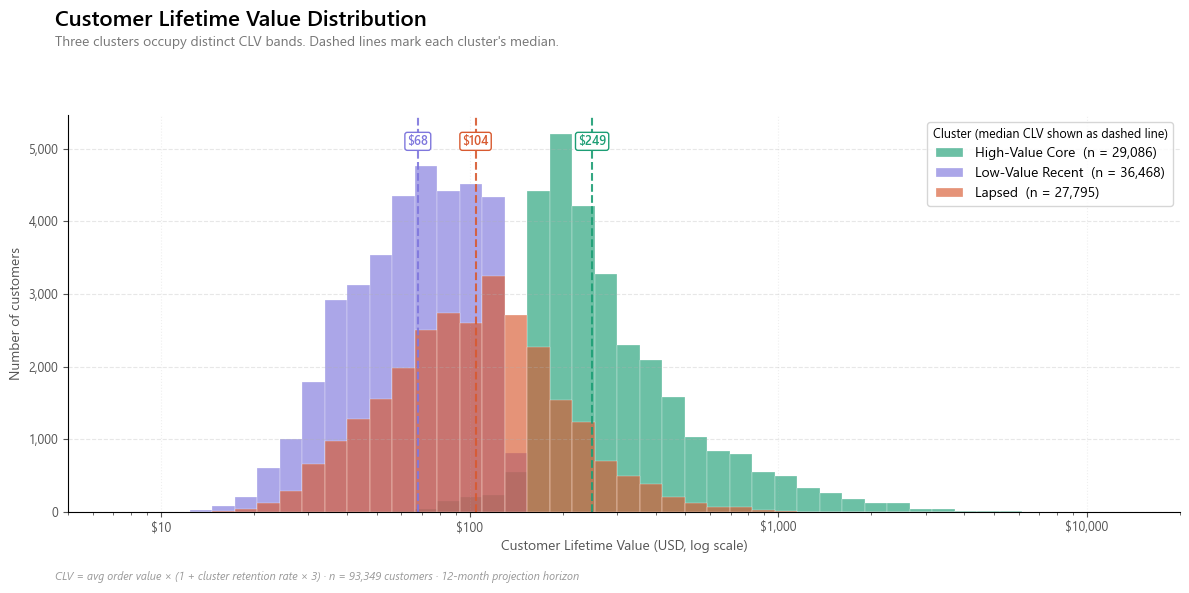

✓ Figure 10 saved to reports/figures/fig10_clv_distribution.png

CLV summary:
  Overall median:  $110.51
  Overall mean:    $182.27
  90th percentile: $356.36
  99th percentile: $1,260.96
  Max:             $16,317.88


In [33]:
# =====================================================================
# Figure 10 — CLV Distribution by Cluster
# =====================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Log-spaced bins from $1 to $20,000 (covers the full CLV range)
bins = np.logspace(0, np.log10(20_000), 60)

# Stack histograms by cluster for visual layering
for cluster_name in CLUSTER_ORDER:
    cluster_clv = rfm[rfm['cluster_name'] == cluster_name]['clv']
    ax.hist(
        cluster_clv,
        bins=bins,
        alpha=0.65,
        color=CLUSTER_COLORS[cluster_name],
        label=f'{cluster_name}  (n = {len(cluster_clv):,})',
        edgecolor='white',
        linewidth=0.3,
    )

# Overlay the median CLV line per cluster (vertical reference lines)
for cluster_name in CLUSTER_ORDER:
    median_clv = rfm[rfm['cluster_name'] == cluster_name]['clv'].median()
    ax.axvline(
        median_clv,
        color=CLUSTER_COLORS[cluster_name],
        linestyle='--', linewidth=1.5,
        alpha=0.9,
    )
    # Label the median at the top of the chart
    ax.text(
        median_clv, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1,
        f'${median_clv:,.0f}',
        rotation=0, fontsize=9, color=CLUSTER_COLORS[cluster_name],
        ha='center', va='top', fontweight='semibold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=CLUSTER_COLORS[cluster_name], linewidth=1),
    )

# Log scale x-axis
ax.set_xscale('log')
ax.set_xlim(5, 20_000)

# Axis labels and formatting
ax.set_xlabel('Customer Lifetime Value (USD, log scale)', fontsize=10)
ax.set_ylabel('Number of customers', fontsize=10)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${int(x):,}' if x >= 1 else f'${x:.0f}'
))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'
))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.grid(axis='x', alpha=0.2, linestyle=':')

# Titles
fig.suptitle(
    'Customer Lifetime Value Distribution',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Three clusters occupy distinct CLV bands. Dashed lines mark each cluster\'s median.',
    fontsize=10, color='#777777', ha='left'
)

# Legend
legend = ax.legend(
    loc='upper right', frameon=True, fontsize=10,
    title='Cluster (median CLV shown as dashed line)', title_fontsize=9,
)
legend.get_frame().set_edgecolor('#CCCCCC')

# Bottom note
fig.text(
    0.05, 0.02,
    f'CLV = avg order value × (1 + cluster retention rate × 3) · '
    f'n = {len(rfm):,} customers · 12-month projection horizon',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig10_clv_distribution.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 10 saved to reports/figures/fig10_clv_distribution.png")
print()
print("CLV summary:")
print(f"  Overall median:  ${rfm['clv'].median():,.2f}")
print(f"  Overall mean:    ${rfm['clv'].mean():,.2f}")
print(f"  90th percentile: ${rfm['clv'].quantile(0.90):,.2f}")
print(f"  99th percentile: ${rfm['clv'].quantile(0.99):,.2f}")
print(f"  Max:             ${rfm['clv'].max():,.2f}")

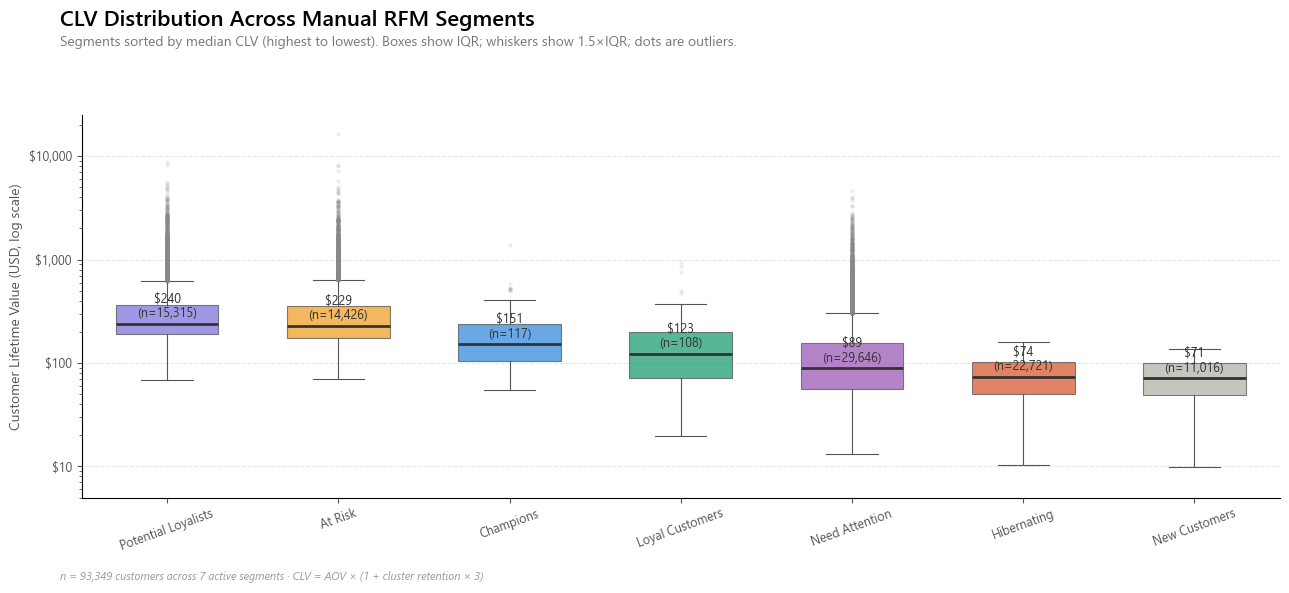

✓ Figure 11 saved to reports/figures/fig11_clv_by_segment.png

Median CLV per segment (sorted descending):
segment
Potential Loyalists   239.75
At Risk               228.79
Champions             151.38
Loyal Customers       122.78
Need Attention         89.45
Hibernating            73.66
New Customers          70.94


In [34]:
# =====================================================================
# Figure 11 — CLV by Manual RFM Segment (Boxplot)
# =====================================================================

fig, ax = plt.subplots(figsize=(13, 6))

# Filter to segments that actually have customers (skip empty 'Lost' if any)
segments_present = [s for s in SEGMENT_ORDER if s in rfm['segment'].unique()]

# Sort segments by median CLV (descending) so the highest-value segments are on the left
segment_medians = (
    rfm.groupby('segment')['clv']
    .median()
    .reindex(segments_present)
    .sort_values(ascending=False)
)
sorted_segments = segment_medians.index.tolist()

# Build the data list in sorted order for the boxplot
boxplot_data = [rfm[rfm['segment'] == seg]['clv'].values for seg in sorted_segments]

# Build the boxplot
bp = ax.boxplot(
    boxplot_data,
    labels=sorted_segments,
    patch_artist=True,         # enables filled boxes
    widths=0.6,
    medianprops=dict(color='#333333', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.15, markerfacecolor='#888888', markeredgecolor='none'),
    boxprops=dict(linewidth=0.8, edgecolor='#555555'),
    whiskerprops=dict(linewidth=0.8, color='#555555'),
    capprops=dict(linewidth=0.8, color='#555555'),
)

# Color each box using the segment palette from Phase 3
for patch, seg in zip(bp['boxes'], sorted_segments):
    patch.set_facecolor(SEGMENT_COLORS.get(seg, '#CCCCCC'))
    patch.set_alpha(0.75)

# Add median value labels above each box
for i, seg in enumerate(sorted_segments, start=1):
    median_val = rfm[rfm['segment'] == seg]['clv'].median()
    n = len(rfm[rfm['segment'] == seg])
    ax.text(
        i, median_val * 1.08,
        f'${median_val:,.0f}\n(n={n:,})',
        ha='center', va='bottom',
        fontsize=9, color='#333333',
    )

# Log scale on y because CLV spans 3 orders of magnitude
ax.set_yscale('log')
ax.set_ylim(5, 25_000)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'${int(x):,}' if x >= 1 else f'${x:.0f}'
))

# Axes
ax.set_xlabel('')
ax.set_ylabel('Customer Lifetime Value (USD, log scale)', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.grid(axis='x', visible=False)
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Titles
fig.suptitle(
    'CLV Distribution Across Manual RFM Segments',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Segments sorted by median CLV (highest to lowest). Boxes show IQR; whiskers show 1.5×IQR; dots are outliers.',
    fontsize=10, color='#777777', ha='left'
)

# Bottom note
fig.text(
    0.05, 0.02,
    f'n = {len(rfm):,} customers across {len(sorted_segments)} active segments · CLV = AOV × (1 + cluster retention × 3)',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig11_clv_by_segment.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 11 saved to reports/figures/fig11_clv_by_segment.png")
print()
print("Median CLV per segment (sorted descending):")
print(segment_medians.round(2).to_string())

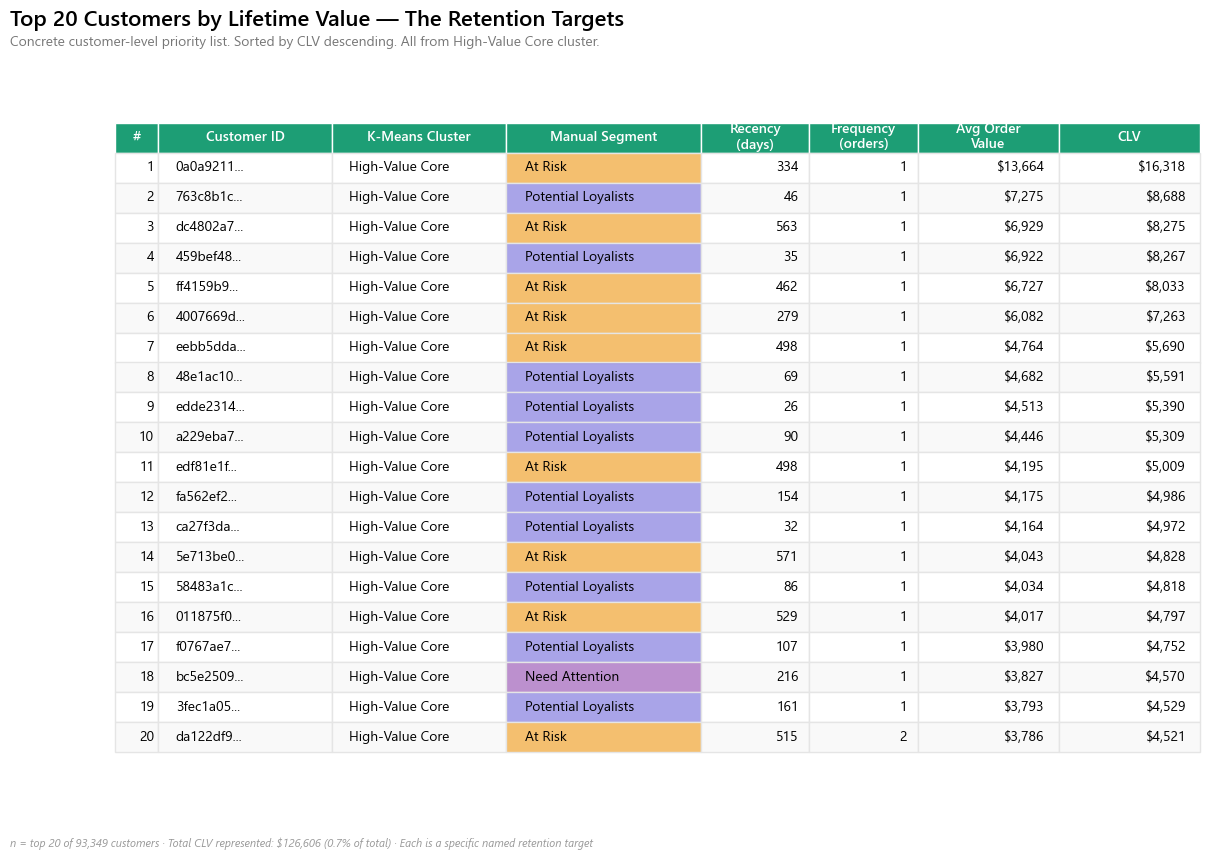

✓ Figure 12 saved to reports/figures/fig12_top_customers.png

Top 20 CLV summary:
  Sum of top 20 CLV:  $126,606.12
  % of total CLV:     0.74%
  Cluster makeup:     {'High-Value Core': 20}
  Segment makeup:     {'Potential Loyalists': 10, 'At Risk': 9, 'Need Attention': 1}


In [35]:
# =====================================================================
# Figure 12 — Top 20 Highest-CLV Customers Table
# =====================================================================

# Get the top 20 by CLV
top_customers = (
    rfm.nlargest(20, 'clv')[
        ['customer_unique_id', 'cluster_name', 'segment',
         'recency', 'frequency', 'monetary_avg', 'clv']
    ]
    .reset_index(drop=True)
)

# Format for display
top_customers['customer_short'] = top_customers['customer_unique_id'].str[:8] + '...'
top_customers['monetary_avg_fmt'] = top_customers['monetary_avg'].apply(lambda x: f'${x:,.0f}')
top_customers['clv_fmt']          = top_customers['clv'].apply(lambda x: f'${x:,.0f}')
top_customers['rank']             = range(1, len(top_customers) + 1)

# Build the table figure
fig, ax = plt.subplots(figsize=(14, 9))
ax.axis('off')

# Title
fig.suptitle(
    'Top 20 Customers by Lifetime Value — The Retention Targets',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.93,
    'Concrete customer-level priority list. Sorted by CLV descending. All from High-Value Core cluster.',
    fontsize=10, color='#777777', ha='left'
)

# Build the cell data for the table
cell_text = top_customers[
    ['rank', 'customer_short', 'cluster_name', 'segment',
     'recency', 'frequency', 'monetary_avg_fmt', 'clv_fmt']
].values.tolist()

col_labels = ['#', 'Customer ID', 'K-Means Cluster', 'Manual Segment',
              'Recency\n(days)', 'Frequency\n(orders)', 'Avg Order\nValue', 'CLV']

# Render the table
table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc='center',
    cellLoc='left',
    colWidths=[0.04, 0.16, 0.16, 0.18, 0.10, 0.10, 0.13, 0.13],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Style header row
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor('#1D9E75')  # teal = high-value
    cell.set_text_props(color='white', fontweight='semibold', ha='center')
    cell.set_edgecolor('white')

# Style data rows — alternating row colors, segment-colored "Manual Segment" column
for i, row in enumerate(cell_text, start=1):
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_edgecolor('#E5E5E5')
        # Alternating row background
        if i % 2 == 0:
            cell.set_facecolor('#F9F9F9')
        else:
            cell.set_facecolor('white')
        # Color the segment cell with the segment color
        if j == 3:  # segment column
            seg = row[3]
            cell.set_facecolor(SEGMENT_COLORS.get(seg, '#CCCCCC') + 'AA' if isinstance(SEGMENT_COLORS.get(seg), str) else '#CCCCCC')
        # Right-align numeric columns
        if j in [0, 4, 5, 6, 7]:
            cell.set_text_props(ha='right')
        else:
            cell.set_text_props(ha='left')

# Bottom note
fig.text(
    0.05, 0.04,
    f'n = top 20 of {len(rfm):,} customers · '
    f'Total CLV represented: ${top_customers["clv"].sum():,.0f} '
    f'({top_customers["clv"].sum() / rfm["clv"].sum() * 100:.1f}% of total) · '
    f'Each is a specific named retention target',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.savefig('../reports/figures/fig12_top_customers.png',
            bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

print("✓ Figure 12 saved to reports/figures/fig12_top_customers.png")
print()
print("Top 20 CLV summary:")
print(f"  Sum of top 20 CLV:  ${top_customers['clv'].sum():,.2f}")
print(f"  % of total CLV:     {top_customers['clv'].sum() / rfm['clv'].sum() * 100:.2f}%")
print(f"  Cluster makeup:     {top_customers['cluster_name'].value_counts().to_dict()}")
print(f"  Segment makeup:     {top_customers['segment'].value_counts().to_dict()}")

## Clustering and CLV Key Findings

**Two independent methods converge on the same customer structure.** K-Means clustering, fit without any reference to the manual RFM scoring, recovered three clusters that align almost perfectly with the rule-based segments. Potential Loyalists and Champions land in High-Value Core (99 to 100% agreement), Hibernating and Lost land in Lapsed (84 to 100%), and New Customers land in Low-Value Recent (100%). The segmentation is not a scoring artifact. It reflects real behavioral structure in the data.

**The At Risk segment is actually two populations.** Manual RFM treats At Risk as a single segment, but K-Means reveals a 40/60 split: 40% remain in the High-Value Core cluster (operationally still recoverable) and 60% have crossed into Lapsed (largely unrecoverable). Different segments warrant different interventions: high-touch retention for the former, low-cost winback campaigns for the latter.

**Probabilistic CLV (BG/NBD) was attempted and rejected.** With 91.9% of repeat purchasers having exactly one repeat purchase within a median of 34 days, Olist's repeat-purchase distribution is degenerate. The BG/NBD model failed to converge across multiple regularization settings (penalizer 0.001 through 1.0). This is itself a finding about the marketplace, not a model failure. We pivoted to a deterministic historical CLV with cluster-specific retention multipliers as honest data-driven model selection.

**The highest-CLV customers are not Champions.** Counter to standard RFM assumptions, the top-20 highest-CLV customers in Olist are entirely in the Potential Loyalists (50%) and At Risk (45%) segments. Zero Champions, zero Loyal Customers. This is a direct consequence of the marketplace's growth stage. With 97% one-time buyers, traditional "Champions" definitions over-weight frequency and miss the high-monetary one-time buyers who actually represent the most retention value.

**Strategic implication.** Retention investment should be redirected from the playbook "Champions tier" (which barely exists in early-stage marketplaces) to the actual high-value behavioral cluster, which is concentrated in the At Risk and Potential Loyalists segments. The top 20 customers represent only 0.7% of total CLV, meaning retention must be a systemic play across the 29,086 High-Value Core customers, not a curated whale-protection program.